<center><h1><b>LET'S FIND $D^0$ DECAYS</b></h1></center>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import awkward as ak
import uproot

from itertools import combinations
import itertools
import os

---

# ACCESSING DATA

In [2]:
! ls /mnt/SingleTrackTrees/Data/alice_data_2023_LHC23f_535087_apass4_1300_Thinner/Output/Run535087

Chunk0950  Chunk1020  Chunk1050  Chunk1120  Chunk1150  Chunk1220
Chunk1000  Chunk1030  Chunk1100  Chunk1130  Chunk1200  Chunk1300
Chunk1010  Chunk1040  Chunk1110  Chunk1140  Chunk1210


In [3]:
! ls -lh /mnt/SingleTrackTrees/Data/alice_data_2023_LHC23f_535087_apass4_1300_Thinner/Output/Run535087/Chunk0950/001_007

total 2.0G
-rwxr-xr-x 1 ubuntu ubuntu 2.0G May 21 08:38 AO2Dtree.root
-rwxr-xr-x 1 ubuntu ubuntu  18K May 21 08:38 AnalysisResults.root
-rwxr-xr-x 1 ubuntu ubuntu  518 May 21 08:38 input_data.txt


For now, we focus on the data of a single chunck of 2GB.

In [4]:
path = "/mnt/SingleTrackTrees/Data/alice_data_2023_LHC23f_535087_apass4_1300_Thinner/Output/Run535087/Chunk0950/001_007/AO2Dtree.root"
file = uproot.open(path)
file.classnames()

{'DF_2298181510431936;1': 'TDirectory',
 'DF_2298181510431936/O2collision_001;1': 'TTree',
 'DF_2298181510431936/O2filtertrack;1': 'TTree',
 'DF_2298181510431936/O2filtertrackextr;1': 'TTree',
 'DF_2298181510502944;1': 'TDirectory',
 'DF_2298181510502944/O2collision_001;1': 'TTree',
 'DF_2298181510502944/O2filtertrack;1': 'TTree',
 'DF_2298181510502944/O2filtertrackextr;1': 'TTree',
 'DF_2298181510571872;1': 'TDirectory',
 'DF_2298181510571872/O2collision_001;1': 'TTree',
 'DF_2298181510571872/O2filtertrack;1': 'TTree',
 'DF_2298181510571872/O2filtertrackextr;1': 'TTree',
 'DF_2298181510572384;1': 'TDirectory',
 'DF_2298181510572384/O2collision_001;1': 'TTree',
 'DF_2298181510572384/O2filtertrack;1': 'TTree',
 'DF_2298181510572384/O2filtertrackextr;1': 'TTree',
 'DF_2298181510642880;1': 'TDirectory',
 'DF_2298181510642880/O2collision_001;1': 'TTree',
 'DF_2298181510642880/O2filtertrack;1': 'TTree',
 'DF_2298181510642880/O2filtertrackextr;1': 'TTree',
 'DF_2298181510718144;1': 'TDirecto

In [5]:
# # debug
# file["DF_2298181510431936/O2filtertrackextr"].show()

In [6]:
# debug
df_test = file["DF_2298181510431936/O2filtertrack"].arrays(library="pd")
df_test.tail(20)

,fIndexCollisions,fIsInsideBeamPipe,fTrackType,fX,fAlpha,fY,fZ,fSnp,fTgl,fSigned1Pt
66806,12539,1,1,0.027249,2.873356,0.039532,-5.667036,2.821338e-07,0.740830,-1.924326
66807,12539,1,1,-0.007118,2.082306,0.046388,-5.665335,-1.346596e-07,0.249703,-1.962505
66808,12539,1,1,0.035687,-1.793978,-0.027459,-5.667980,7.385800e-08,-0.453743,-1.246107
66809,12539,1,1,0.045376,-2.627455,0.006573,-5.669346,3.186306e-07,0.569641,-2.814809
66810,12540,1,1,-0.006714,1.971335,0.050580,-0.897414,-3.104690e-07,-0.326134,1.294014
66811,12540,1,1,0.013823,2.386948,0.051357,-0.893160,1.761223e-07,-0.328728,-1.553554
66812,12540,1,1,-0.040647,1.154443,0.030030,-0.894317,1.802687e-06,-0.653793,-2.914980
66813,12540,1,1,-0.048835,0.328047,-0.009122,-0.895774,-4.881810e-07,-0.629257,1.309301
66814,12541,1,1,0.044518,-2.313488,-0.006762,0.071578,4.606761e-07,0.644058,-1.252301
66815,12541,1,1,0.035573,-1.883195,-0.024469,0.070390,-9.863758e-09,-0.156296,0.852236


---

## PRE-WRITTEN CUTS
We write the cuts that will be used as boolean masks through the pd.eval function. Watch out for extra spaces and things like that.

In [7]:
# NSigmaTPC:
sigma_limit = 3
cut1 = (
    "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
    "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
)

# NsigmaTOF:
sigma_limit = 3
cut2 = (
    "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
    "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
    "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
)

# DCA_XY:
cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# FINAL CUT EXPRESSION:
cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

## DATA INTO PANDAS DATAFRAME

In [8]:
# # CODE FOR UNIFYING EVERY ROOT FILE

# # let's build each path to every ROOT file:
# base = "/mnt/SingleTrackTrees/Data/alice_data_2023_LHC23f_535087_apass4_1300_Thinner/Output/Run535087"
# mid = ["Chunk0950/001_007", "Chunk1000/001_005", "Chunk1000/006_009", "Chunk1010/001_005", "Chunk1010/006_010"]  # ne mancano...
# final = "AO2Dtree.root"

# paths = []
# for mid_path in mid:
#     unified_path = os.path.join(base, mid_path, final)
#     paths.append( unified_path )
#     print( unified_path )

In [9]:
# debug
names_coll       = file.keys(filter_name=r"*O2collision_001")
print( len(names_coll) )   # numero di T-Directories nel file root aperto

447


In [10]:
# # debug:
# names_coll       = file.keys(filter_name=r"*O2collision_001")
# values_coll = pd.concat( [ file[item].arrays(["fPosZ"], library="pd") for item in names_coll[0:20] ], ignore_index=True )
# values_coll

In [11]:
# # debug
# names_track      = file.keys(filter_name=r"*O2filtertrack")
# num=10
# values_track      = pd.concat( [ file[item]\
#     .arrays(["fIndexCollisions", "fAlpha"], library="pd") for item in names_track[0:num] ], ignore_index=True )
# fig,ax = plt.subplots(figsize=(13,3))
# y_val = values_track["fIndexCollisions"]
# plt.hist( y_val[ (y_val>-100) & (y_val<25) ] , bins=1000)
# plt.show()

In [12]:
import gc

# CODE FOR UNIFYING DIRECTORIES OF A SINGLE ROOT FILE from all three type of T-Trees:

# Load T-Trees from directories
names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
names_track      = file.keys(filter_name=r"*O2filtertrack")
names_coll       = file.keys(filter_name=r"*O2collision_001")
num = 400   # number of directories to unify
# if I try with all, it crashes, because in this notebook I'm doing the cuts only after loading all data (in order tp study the cuts)

list_of_df = []               # add the dataframes in a list (we will concat them later)

collision_offset = 0          # variable to correct the index of the collision (because it starts from 0 at each new TTree)

for i in range(num):          # cycle over directories (each with 3 TTrees)
    
    # Read collision tree
    df_coll = file[ names_coll[i] ].arrays(["fPosZ"], library="pd")   # I take the fPosZ column as a DataFrame
    # list_of_collision_df.append(df_coll)               # add the dataframe in a list (we will concat them later)

    # # Read track and trackextr using boolean mask for track and trackextr:
    df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
         "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr", "fNsigmaTOFpi", "fNsigmaTOFka", "fNsigmaTOFpr"], library="pd" )
    df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha"], library="pd")
    mask = df_trackextr.eval(cut_expression)        # create boolean mask
    # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
    df_trackextr = df_trackextr.loc[mask, ["fPt", "fEta", "fCharge", "fDcaXY"] ].reset_index(drop=True)
    df_track = df_track.loc[mask,].reset_index(drop=True)
    # merging in a single dataframe
    df_trackextr["fIndexCollisions"] = df_track["fIndexCollisions"] 
    df_trackextr["fAlpha"] = df_track["fAlpha"]

    # we cut rows where the fIndexCollision is negative (for some reason)
    valid = df_track["fIndexCollisions"] >= 0
    df_track = df_track[valid].reset_index(drop=True)          
    df_trackextr = df_trackextr[valid].reset_index(drop=True)  

    
    # Now we for correct fPosZ (and add that column)
    df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
    df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
    df_trackextr["fIndexCollisions"] += collision_offset   # Fix local fIndexCollisions → global index 

    # save results:
    # ALTERNATIVE 1: for the first cycle, let's copy the first dataframe, then we concatenate the next ones
    if  i==0: df = df_trackextr
    else: df = pd.concat([df, df_trackextr], ignore_index=True)
    # # ALTERNATIVE 2:
    # list_of_df.append( df_trackextr )                  # add the dataframe in a list (we will concat them later)
    
    # Update offset for next loop
    collision_offset += len(df_coll)     

    # let's free the memory RAM of unused dataframes:
    del df_trackextr
    del df_track
    gc.collect()


# # UNCOMMENT FOR ALTERNATIVE 2:
# df = pd.concat(list_of_df, ignore_index=True)

# Merge everything in the total dataframe
N = len(df)

In [13]:
# debug
print("The dataframe has", len(df), "rows")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The dataframe occupy {memory:.2f} MB")
df

The dataframe has 14431028 rows
The dataframe occupy 385.35 MB


,fPt,fEta,fCharge,fDcaXY,fIndexCollisions,fAlpha,fPosZ
0,0.311392,0.052986,1,-0.005521,0,-1.053308,0.354504
1,0.884602,-0.032689,-1,-0.001190,0,1.075205,0.354504
2,1.256379,0.315822,-1,-0.001517,0,-1.198550,0.354504
3,0.394436,-0.480611,1,0.015037,0,-1.967123,0.354504
4,1.416420,-0.431723,-1,0.003487,0,-1.708177,0.354504
...,...,...,...,...,...,...,...
14431023,0.307252,0.109766,1,-0.003527,4947771,2.976197,-7.584023
14431024,0.307353,-0.136470,1,0.003662,4947771,-0.947150,-7.584023
14431025,0.316271,0.237626,1,0.052190,4947771,1.177254,-7.584023
14431026,0.332755,-0.529478,1,0.002178,4947772,2.266506,3.548855


---

#### dcaXY
This variable for the background should be around 0, for the signal different from 0. So we cut the central values.

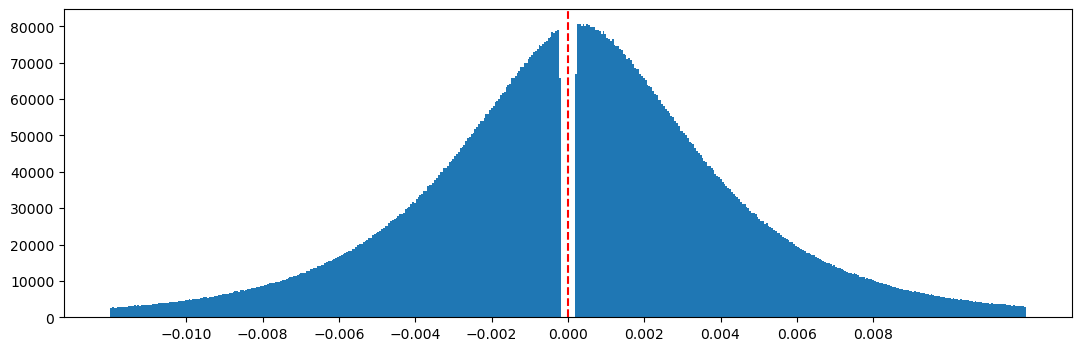

In [14]:
dca_xy = np.array( df['fDcaXY'] )

# filter:
dca_xy_filt = dca_xy[(dca_xy > -0.012) & (dca_xy < 0.012)]
fig,ax = plt.subplots(figsize=(13,4))
ax.hist(dca_xy_filt, bins=500)
plt.axvline(x=0, color='r', linestyle='--', label='x = 0')
plt.xticks( np.arange(-0.01, 0.01, 0.002) )
plt.show()

#### $p_t$

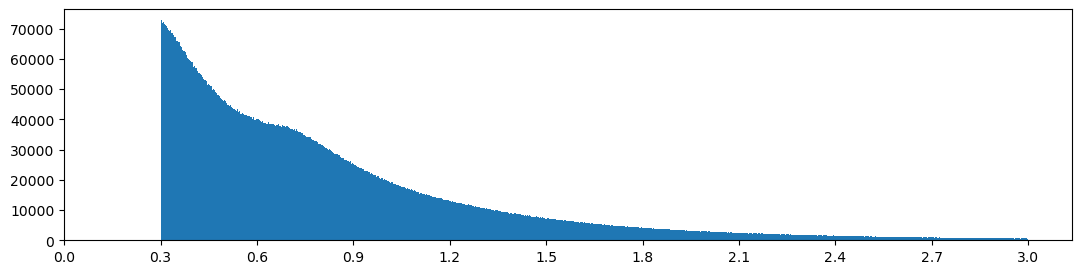

In [15]:
pt = np.array( df['fPt'] )

# plot
fig,ax = plt.subplots(figsize=(13,3))
pt_filt = pt[ pt<3 ]
ax.hist(pt_filt, bins=1000)
plt.xticks( np.arange(0, 3.1, 0.3) )
plt.show()

---

# PAIR VARIABLES CUTS
Let's search for couples of particles coming from the same collision (through "fIndexCollisions"), with opposite charge (for $K^-$ and $\pi^+$), and plot their $dcaXY \cdot dcaXY$ distribution.

We do it creating a new dataframe where we save the index of each particle in the pair (in this way we have a connection with the original dataframe) and the product of dcaXY of the two particles.

In [16]:
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

#### INVARIANT MASS
The general formula for the invariant mass $M$ of two particles is:

$$
M^2 = (E_1 + E_2)^2 - |\vec{p}_1 + \vec{p}_2|^2
$$

Expanding the momentum vector components: $ M^2 = (E_1 + E_2)^2 - (p_{x1} + p_{x2})^2 - (p_{y1} + p_{y2})^2 - (p_{z1} + p_{z2})^2 $

This can also be written as: $ M = \sqrt{(E_1 + E_2)^2 - (\vec{p}_1 + \vec{p}_2)^2} $

The energy $E_i$ of each particle is computed using the relativistic relation:

$$
E_i = \sqrt{|\vec{p}_i|^2 + m_i^2}
$$

In our detector data, we are given the transverse momentum $p_T$, the pseudorapidity $\eta$, and the azimuthal angle $\alpha$ (denoted as $fPt$, $fEta$, and $fAlpha$). We can compute the three components of momentum for each track using the following relations:

$$
p_x = p_T \cdot \cos(\alpha)
$$

$$
p_y = p_T \cdot \sin(\alpha)
$$

$$
p_z = p_T \cdot \sinh(\eta)
$$

Then, the full momentum magnitude is:

$$
|\vec{p}| = \sqrt{p_T^2 \cdot \cosh^2(\eta)} = p_T \cdot \cosh(\eta)
$$

So the energy of each particle becomes:

$$
E = \sqrt{(p_T \cdot \cosh(\eta))^2 + m^2}
$$

And we can compute the invariant mass in our case with:
$$
M^2 = (E_K + E_\pi)^2 - (p_{x,K} + p_{x,\pi})^2 - (p_{y,K} + p_{y,\pi})^2 - (p_{z,K} + p_{z,\pi})^2
$$

---
We can also use an approximated expression for the invariant mass, valid in the ultra-relativistic limit ($m \ll E$), where masses are neglected:


$$
M \approx \sqrt{2 \cdot p_{T1} \cdot p_{T2} \cdot \left( \cosh(\eta_1 - \eta_2) - \cos(\alpha_1 - \alpha_2) \right)}
$$

In [17]:
# let's RESET the indexes of df:
# WATCH OUT: Resetting the index creates a new DataFrame copy. 
# If df is huge, this can cause your system to run out of RAM, leading to a kernel crash.
# df = df.reset_index(drop=True)

Let's compute the variables (adding them as columns) for the invariant mass before the iterations ot the for loop. In this way we save computation time. The downside will be the heavier dataframe weight.

In [18]:
# moment columns:
df["px"] = df["fPt"] * np.cos(df["fAlpha"])
df["py"] = df["fPt"] * np.sin(df["fAlpha"])
df["pz"] = df["fPt"] * np.sinh(df["fEta"])

# energy column (differentiating pions and kaons):
mass = np.where(df["fCharge"] > 0, m_pi, m_K)
df["Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mass**2)

In [19]:
# Debug
print("The dataframe has", len(df), "rows")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The dataframe occupy {memory:.2f} MB")
df

The dataframe has 14431028 rows
The dataframe occupy 660.60 MB


,fPt,fEta,fCharge,fDcaXY,fIndexCollisions,fAlpha,fPosZ,px,py,pz,Ene
0,0.311392,0.052986,1,-0.005521,0,-1.053308,0.354504,0.154045,-0.270620,0.016507,0.341639
1,0.884602,-0.032689,-1,-0.001190,0,1.075205,0.354504,0.420674,0.778174,-0.028922,1.013447
2,1.256379,0.315822,-1,-0.001517,0,-1.198550,0.354504,0.456956,-1.170333,0.403421,1.408883
3,0.394436,-0.480611,1,0.015037,0,-1.967123,0.354504,-0.152265,-0.363861,-0.196953,0.462439
4,1.416420,-0.431723,-1,0.003487,0,-1.708177,0.354504,-0.193978,-1.403075,-0.630675,1.627180
...,...,...,...,...,...,...,...,...,...,...,...
14431023,0.307252,0.109766,1,-0.003527,4947771,2.976197,-7.584023,-0.303059,0.050587,0.033794,0.339155
14431024,0.307353,-0.136470,1,0.003662,4947771,-0.947150,-7.584023,0.179494,-0.249495,-0.042075,0.340170
14431025,0.316271,0.237626,1,0.052190,4947771,1.177254,-7.584023,0.121278,0.292094,0.075864,0.353925
14431026,0.332755,-0.529478,1,0.002178,4947772,2.266506,3.548855,-0.213273,0.255423,-0.184535,0.405289


WATCH OUT: fIndexCollisions has million of values, meaning millions of collision groups, and if you do a groupby with it, it will crash the kernel.

EXPECTED COMPUTATION TIME OF NEXT CODE: around 45min for 1 million collision groups.

```python
# ALTERNATIVE 0
# let's initialize a list, then we will create a dataframe
pairs = []

# Iterate over each collision group
for collision_idx, group in df.groupby('fIndexCollisions'):

    # Only collisions with at least 2 tracks
    if len(group) < 2: continue

    # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
    group = group.reset_index().rename(columns={'index': 'orig_index'})

    # Iterate over all unique pairs of tracks
    for i1, i2 in combinations(range(len(group)), 2):
        row1 = group.iloc[i1]
        row2 = group.iloc[i2]

        # only pairs with opposite charge
        if row1['fCharge'] * row2['fCharge'] < 0:
            product_dcaXY = row1['fDcaXY'] * row2['fDcaXY']

            if row1['fCharge'] > 0: pos, neg = row1, row2
            else:                   pos, neg = row2, row1
            
            # INVARIANT MASS calculation
            pt1, pt2 = pos['fPt'], neg['fPt']
            eta1, eta2 = pos['fEta'], neg['fEta']
            phi1, phi2 = pos['fAlpha'], neg['fAlpha']
            delta_eta = eta1 - eta2
            delta_phi = phi1 - phi2

            # approximation formula
            inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))

            # exact formula:
            E1 = np.sqrt( (pt1*np.cosh(eta1))**2 + m_pi**2 )
            E2 = np.sqrt( (pt2*np.cosh(eta2))**2 + m_K**2 )
            px1 = pt1*np.cos(phi1)
            py1 = pt1*np.sin(phi1)
            pz1 = pt1*np.sinh(eta1)
            px2 = pt2*np.cos(phi2)
            py2 = pt2*np.sin(phi2)
            pz2 = pt2*np.sinh(eta2)
            inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )


            # total transverse momentum of the D0 candidate (used later for sliced plots)
            pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)

            # let's add the found pairs to the list
            pairs.append({
                'collision_index': int(row1['fIndexCollisions']),
                'track1_index': int(row1['orig_index']),
                'track2_index': int(row2['orig_index']),
                'dcaXY_product': product_dcaXY,
                'inv_mass': inv_mass,
                'inv_mass_approx': inv_mass_approx,
                'pt': pt_total
            })


# create a dataframe with the result:
df_pairs = pd.DataFrame(pairs)
```

```python
# ALTERNATIVE 1:
# let's initialize a list, then we will create a dataframe
pairs = []
i=0 # debug variable

# Iterate over each collision group
for collision_idx in df['fIndexCollisions'].unique():
    group = df[ df['fIndexCollisions'] == collision_idx ]

    # Only collisions with at least 2 tracks
    if len(group) < 2: continue
        
    # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
    group = group.reset_index().rename(columns={'index': 'orig_index'})

    # Iterate over all unique pairs of tracks
    for i1, i2 in combinations(range(len(group)), 2):
        row1 = group.iloc[i1]
        row2 = group.iloc[i2]

        # only pairs with opposite charge
        if row1['fCharge'] * row2['fCharge'] < 0:
            product_dcaXY = row1['fDcaXY'] * row2['fDcaXY']

            if row1['fCharge'] > 0: pos, neg = row1, row2
            else:                   pos, neg = row2, row1
            
            # INVARIANT MASS calculation
            pt1, pt2 = pos['fPt'], neg['fPt']
            eta1, eta2 = pos['fEta'], neg['fEta']
            phi1, phi2 = pos['fAlpha'], neg['fAlpha']
            delta_eta = eta1 - eta2
            delta_phi = phi1 - phi2

            # approximation formula
            inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))

            # exact formula:
            E1 = np.sqrt( (pt1*np.cosh(eta1))**2 + m_pi**2 )
            E2 = np.sqrt( (pt2*np.cosh(eta2))**2 + m_K**2 )
            px1 = pt1*np.cos(phi1)
            py1 = pt1*np.sin(phi1)
            pz1 = pt1*np.sinh(eta1)
            px2 = pt2*np.cos(phi2)
            py2 = pt2*np.sin(phi2)
            pz2 = pt2*np.sinh(eta2)
            inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )


            # total transverse momentum of the D0 candidate (used later for sliced plots)
            pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)

            # let's add the found pairs to the list
            pairs.append({
                'collision_index': int(row1['fIndexCollisions']),
                'track1_index': int(row1['orig_index']),
                'track2_index': int(row2['orig_index']),
                'dcaXY_product': product_dcaXY,
                'inv_mass': inv_mass,
                'inv_mass_approx': inv_mass_approx,
                'pt': pt_total
            })

    # let's free the memory RAM of unused dataframes:
    # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    del group
    gc.collect()
    
    # debug:
    i += 1
    if i % 100 ==0: print(i, end=' ')

# create a dataframe with the result:
df_pairs = pd.DataFrame(pairs)
```

```python
# ALTERNATIVE 2:
# let's initialize some lists, then we will create a dataframe
collision_indices = []
track1_indices = []
track2_indices = []
dcaXY_products = []
inv_masses = []
inv_masses_approx = []
pt_totals = []

i=0 # debug variable

# Iterate over each collision group
for collision_idx in df['fIndexCollisions'].unique():
    group = df[ df['fIndexCollisions'] == collision_idx ]

    # Only collisions with at least 2 tracks
    if len(group) < 2: continue
        
    # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
    group = group.reset_index().rename(columns={'index': 'orig_index'})

    # Iterate over all unique pairs of tracks
    for i1, i2 in combinations(range(len(group)), 2):
        row1 = group.iloc[i1]
        row2 = group.iloc[i2]

        # only pairs with opposite charge
        if row1['fCharge'] * row2['fCharge'] < 0:
            product_dcaXY = row1['fDcaXY'] * row2['fDcaXY']

            if row1['fCharge'] > 0: pos, neg = row1, row2
            else:                   pos, neg = row2, row1
            
            # INVARIANT MASS calculation
            pt1, pt2 = pos['fPt'], neg['fPt']
            eta1, eta2 = pos['fEta'], neg['fEta']
            phi1, phi2 = pos['fAlpha'], neg['fAlpha']
            delta_eta = eta1 - eta2
            delta_phi = phi1 - phi2

            # approximation formula
            inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))

            # exact formula:
            E1 = pos['Ene']
            E2 = neg['Ene']
            px1 = pos["px"]
            py1 = pos["py"]
            pz1 = pos["pz"]
            px2 = neg["px"]
            py2 = neg["py"]
            pz2 = neg["pz"]
            inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )


            # total transverse momentum of the D0 candidate (used later for sliced plots)
            pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)

            # let's add the found pairs to the lists
            collision_indices.append(int(row1['fIndexCollisions']))
            track1_indices.append(int(row1['orig_index']))
            track2_indices.append(int(row2['orig_index']))
            dcaXY_products.append(product_dcaXY)
            inv_masses.append(inv_mass)
            inv_masses_approx.append(inv_mass_approx)
            pt_totals.append(pt_total)

    # # let's free the memory RAM of unused dataframes:
    # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    # del group
    # gc.collect()

    # debug:
    i += 1
    if i % 10000 ==0: print(i, end=' ')


# create a dataframe with the result:
df_pairs = pd.DataFrame({
    'collision_index': collision_indices,
    'track1_index': track1_indices,
    'track2_index': track2_indices,
    'dcaXY_product': dcaXY_products,
    'inv_mass': inv_masses,
    'inv_mass_approx': inv_masses_approx,
    'pt': pt_totals
})
```

In [ ]:
# ALTERNATIVE 3:
# let's initialize some lists, then we will create a dataframe
collision_indices = []
track1_indices = []
track2_indices = []
dcaXY_products = []
inv_masses = []
inv_masses_approx = []
pt_totals = []

i=0 # debug variable

# let's divide the dataframe for positive and negative charged
df_pos = df[ df['fCharge']>0 ]
df_neg = df[ df['fCharge']<0 ]

# Iterate over each collision group
for collision_idx in df_neg['fIndexCollisions'].unique():
    group_pos = df_pos[ df_pos['fIndexCollisions'] == collision_idx ]
    group_neg = df_neg[ df_neg['fIndexCollisions'] == collision_idx ]

    # Only collisions with at least a pair
    if len(group_pos) < 1:   continue

    # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
    group_pos = group_pos.reset_index().rename(columns={'index': 'orig_index'})
    group_neg = group_neg.reset_index().rename(columns={'index': 'orig_index'})

    # let's crate indexes for all possible pairs:
    combinat = itertools.product( range(len(group_neg)), range(len(group_pos)) )

    # Iterate over all unique pairs of tracks
    for combo in combinat:
        row_neg = group_neg.iloc[combo[0]]
        row_pos = group_pos.iloc[combo[1]]

        product_dcaXY = row_neg['fDcaXY'] * row_pos['fDcaXY']
        
        # INVARIANT MASS calculation
        pt1, pt2 = row_neg['fPt'], row_pos['fPt']
        eta1, eta2 = row_neg['fEta'], row_pos['fEta']
        phi1, phi2 = row_neg['fAlpha'], row_pos['fAlpha']
        delta_eta = eta1 - eta2
        delta_phi = phi1 - phi2

        # approximation formula
        inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))

        # exact formula:
        E1 = row_neg['Ene']
        E2 = row_pos['Ene']
        px1 = row_neg["px"]
        py1 = row_neg["py"]
        pz1 = row_neg["pz"]
        px2 = row_pos["px"]
        py2 = row_pos["py"]
        pz2 = row_pos["pz"]
        inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )


        # total transverse momentum of the D0 candidate (used later for sliced plots)
        pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)

        # let's add the found pairs to the lists
        collision_indices.append(int(row_neg['fIndexCollisions']))
        track1_indices.append(int(row_neg['orig_index']))
        track2_indices.append(int(row_pos['orig_index']))
        dcaXY_products.append(product_dcaXY)
        inv_masses.append(inv_mass)
        inv_masses_approx.append(inv_mass_approx)
        pt_totals.append(pt_total)

    # # let's free the memory RAM of unused dataframes:
    # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    # del group
    # gc.collect()

    # debug:
    i += 1
    if i % 10000 ==0: print(i, end=' ')


# create a dataframe with the result:
df_pairs = pd.DataFrame({
    'collision_index': collision_indices,
    'track1_index': track1_indices,
    'track2_index': track2_indices,
    'dcaXY_product': dcaXY_products,
    'inv_mass': inv_masses,
    'inv_mass_approx': inv_masses_approx,
    'pt': pt_totals
})

In [ ]:
# Debug
print("The dataframe has", len(df_pairs), "rows")
memory = df_pairs.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The dataframe occupy {memory:.2f} MB")
df_pairs

In [ ]:
# df_pairs.to_csv('output_pairs.csv', index=False)

In [ ]:
! ls -lh

#### DcaXY product PLOT

In [ ]:
# Plot histogram
fig,ax = plt.subplots(2,1,figsize=(13,4))
ax[0].hist(df_pairs['dcaXY_product'], bins=300)
ax[0].set_ylabel("Counts")
ax[0].set_title("DCAxy product distribution (opposite charge pairs)")
# filter plot:
prod = df_pairs['dcaXY_product']
prod_filt = prod[ (prod>-0.00001) & (prod<0.00001) ]
ax[1].hist(prod_filt, bins=300)
ax[1].set_ylabel("Counts")
ax[1].set_xlabel("Product of DCAxy")


plt.show()

Il motivo del buco centrale è dovuto al cut iniziale sulla dcaXY, che taglia i valori vicini allo 0.

#### INAVARIANT MASS PLOT

In [ ]:
pt_bins = [(0, 0.5), (0.5, 1), (1.5, 2), (2, 3), (3,100)]  # define your pt slices here

for pt_min, pt_max in pt_bins:
    df_slice = df_pairs[(df_pairs['pt'] >= pt_min) & (df_pairs['pt'] < pt_max)]
    val = df_slice["inv_mass"]

    fig, ax = plt.subplots(2, 1, figsize=(13, 4))
    fig.suptitle(f"Invariant Mass for {pt_min} < $p_T$ < {pt_max} GeV/c", fontsize=14)

    # full-range plot
    ax[0].hist(val[val < 4], bins=500)
    ax[0].axvline(x=m_d0, color='red', linestyle='--', linewidth=1.5, label='$D^0$ mass')
    ax[0].legend()
    ax[0].set_ylabel("Counts")

    # zoom-in plot
    zoom_val = val[(val > 1.8) & (val < 1.9)]
    ax[1].hist(zoom_val, bins=500)
    ax[1].axvline(x=m_d0, color='red', linestyle='--', linewidth=1.5, label='$D^0$ mass')
    ax[1].legend()
    ax[1].set_xlabel("Invariant Mass [$GeV/c^2$]")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()
